In [ ]:
import numpy as np
import astropy.units as u
from astropy.units import Quantity
import astropy.constants as const
from astropy.coordinates import SkyCoord
from scipy import integrate
from scipy.special import erfc, erf
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from cycler import cycler

from tqdm import tqdm
from pathlib import Path
import itertools
import copy
import warnings

from histpy import Histogram, Axes, Axis, HealpixAxis
import healpy as hp
import mhealpy as mhp
from mhealpy import HealpixMap, HealpixBase
from scoords import Attitude, SpacecraftFrame

from cosipy.response import FullDetectorResponse, DetectorResponse, PointSourceResponse
from cosipy import UnBinnedData, BinnedData, test_data
from FullDetectorResponseNew import FullDetectorResponse
from DetectorResponseNew import DetectorResponse
from cosipy.spacecraftfile import SpacecraftFile

from astromodels import PointSource
from lmfit.models import gaussian
from threeML import Model, Powerlaw, Gaussian, Constant, Band
from threeML import PluginPrototype, Model, JointLikelihood, DataList
from threeML.utils.statistics.likelihood_functions import poisson_log_likelihood_ideal_bkg

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['orange', 'limegreen', 'b', 'r']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

DATA_DIR = Path('/Users/penguin/Documents/Research/COSI/COSIpy/docs/DC3/')
response_path = DATA_DIR / 'data/responses/Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.h5'
# response_path = DATA_DIR / 'data/responses/SMEXv12.44Ti.HEALPix04.E_1143_1171keV.binnedimaging.imagingresponse.nonsparse_nside16.area.h5'

07:57:43 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=896914;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=23390;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=268343;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=729893;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=62519;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=403856;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=545359;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=380259;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

07:57:45 WARNING   No fermitools installed                                              ]8;id=190843;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=231321;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

07:57:45 WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=138668;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=737190;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=356996;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=60826;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=994762;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=630104;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
pix = 0

with FullDetectorResponse.open(response_path) as f:
    print(f.__dict__)
    dr = f[pix]

{'_file': <HDF5 file "Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.h5" (mode r)>, '_drm': <HDF5 group "/DRM" (2 members)>, '_unit': Unit("cm2"), '_sparse': False, '_axes': <histpy.axes.Axes object at 0x104763a60>, '_pix_rangesets': None, '_pix_rangesets_argsort': None, '_uniq': None, '_scheme': 'RING', '_order': 4, '_coordsys': <SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>, '_npix_ratio_max': 1125899906842624}


#### RSP Investigation

In [5]:
with FullDetectorResponse.open(response_path) as f:
    rsp = np.array(f._file['DRM']['CONTENTS'])

In [94]:
(rsp.sum(axis=(2,3,4)) / dr.get_effective_area().contents.value)

array([[1.        ],
       [1.00032745],
       [0.99946126],
       ...,
       [0.14320536],
       [0.1576296 ],
       [0.15834823]])

Text(0.5, 1.0, 'Healpix Map [2000:]')

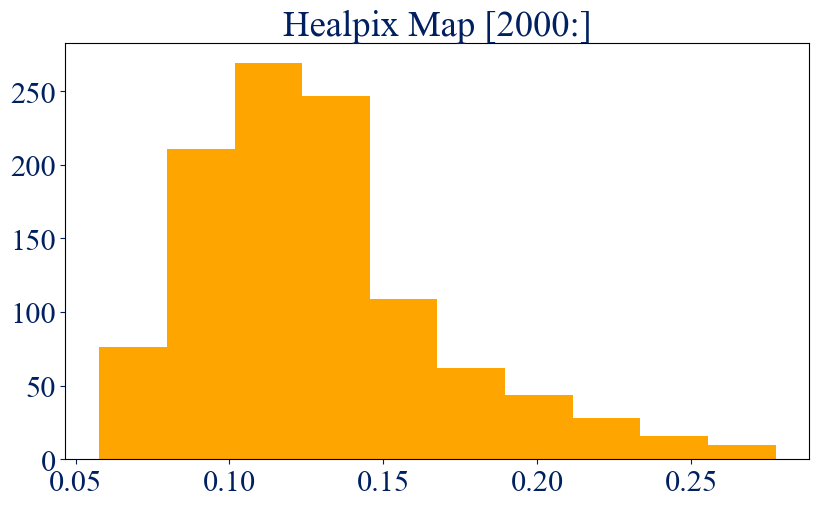

In [41]:
plt.hist((rsp.sum(axis=(2,3,4)) / dr.get_effective_area().contents)[2000:])
plt.title('Healpix Map [2000:]')

### Data

In [3]:
name = 'CasAsymmetric'
point_source = UnBinnedData(DATA_DIR / '44Ti/inputs.yaml')
data = point_source.get_dict_from_fits(DATA_DIR / f'44Ti/sources/{name}_3months_unbinned_data_filtered_with_SAAcut.fits')

target_coord = SkyCoord.from_name('Cas A').galactic
l = target_coord.l.value
b = target_coord.b.value

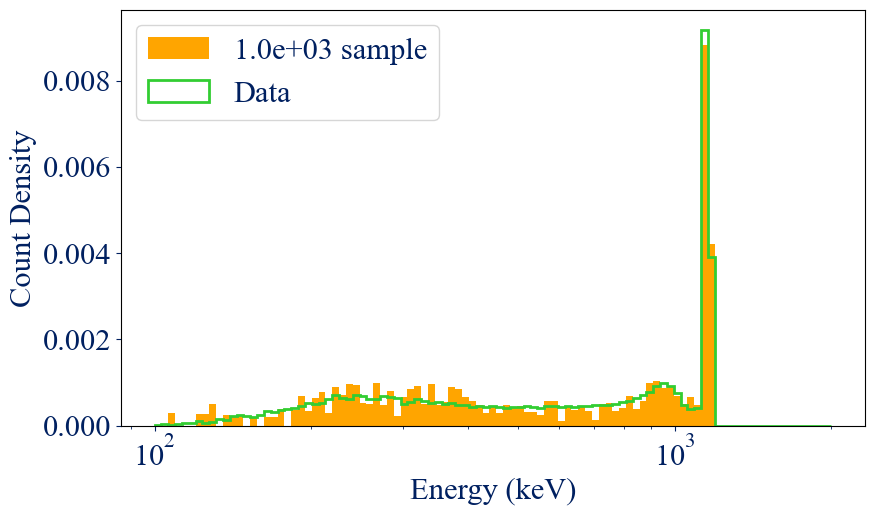

In [ ]:
num_samples = 1000
nside = 32

bins = np.logspace(2, 3.3, 100)*u.keV
# plt.xlim([1100, 1200])
indices = np.random.choice(np.arange(len(data['Energies'])), num_samples, replace=False)
energy_samples = data['Energies'][indices] * u.keV
phi_samples = data['Phi'][indices] * u.rad
psi_gal_samples = data['Psi galactic'][indices] * u.deg
chi_gal_samples = data['Chi galactic'][indices] * u.deg

plt.hist(energy_samples, bins=bins, density=True, label=f'{num_samples:.1e} sample')
plt.hist(data['Energies'], bins=bins.value, density=True, lw=2, histtype='step', label='Data')
plt.xlabel('Energy (keV)')
plt.ylabel('Count Density')
plt.xscale('log')
plt.legend()
plt.show()

In [466]:
s2 = np.sqrt(2)
tiny = 1e-12

def energy_redistribution_expgaussian(Em, Ei, sigma_e, tau_e):    
    # Exponentially modified gaussian smearing kernel: models probability of detecting Em given true energy Ei
    gss = -sigma_e * sigma_e / tau_e
    arg1 = -(Ei + gss/2.0 - Em) / tau_e
    arg2 = (Ei + gss - Em)/max((tiny), (s2 * sigma_e))
    return 1 / (2 * tau_e) * np.exp(arg1) * (erf(arg2) + 1)

In [600]:
def energy_redistribution_expgaussian_with_step(Em, Ei, sigma_e, tau_e, A_tail, sigma_t, m_slope, Em0_linear):
    # Hardcoding
    sigma_t = sigma_e
    A_tail = 0

    gss = -sigma_e * sigma_e / tau_e
    arg1 = -(Ei + gss/2.0 - Em) / tau_e
    arg2 = (Ei + gss - Em)/max((tiny), (s2 * sigma_e))
    tail = A_tail * erfc((Em - Ei) / sigma_t)
    right_triangle = m_slope * np.heaviside(Em - Em0_linear, 1) * np.heaviside(Ei - Em, 1) * (Em - Em0_linear)
    right_triangle_area = 0.5 * m_slope * (Ei - Em0_linear)**2
    return (1 / (2 * tau_e) * np.exp(arg1) * (erf(arg2) + 1) + tail + right_triangle) / (1 + A_tail + right_triangle_area)        # Denominator for normalization

In [ ]:
instrument_broadening = 5.3/2.355       # keV
doppler_broadening = 1.63               # 3.85 keV (FWHM for 1000 km/s expanding shell) / 2.355
np.sqrt(instrument_broadening**2 + doppler_broadening**2)

2.77881068386552

In [233]:
sigma_e = 2.77
tau_e = 3.
Ei = np.linspace(1141, 1199, 30)
x = np.linspace(1141, 1199, 30)

l = []
for E in Ei:
    l.append(energy_redistribution_expgaussian(x, E, sigma_e, tau_e))

In [ ]:
def energy_redistribution_double_expgaussian(Em, Ei, sigma_e, w1, tau_1, w2, tau_2):
    return w1 * energy_redistribution_expgaussian(Em, Ei, sigma_e, tau_1) + \
           w2 * energy_redistribution_expgaussian(Em, Ei, sigma_e, tau_2)

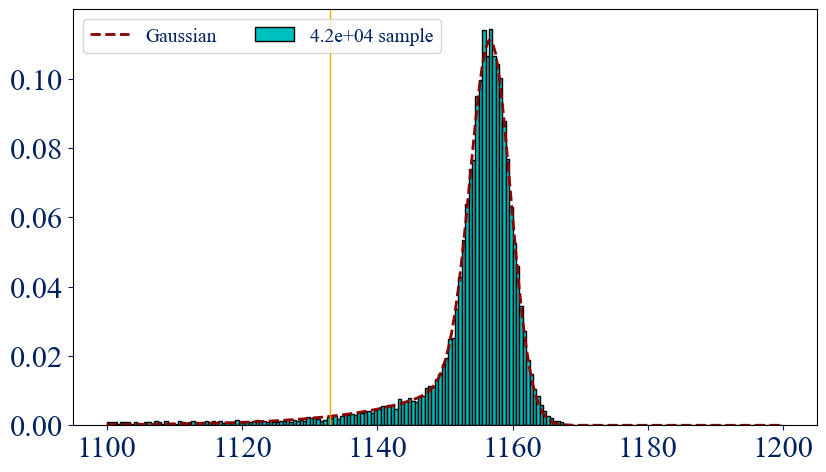

In [657]:
# for i in range(5):
#     idx = 10*i
#     plt.step(x, l[idx], where='mid', lw=2, label=f'{Ei[idx]}')
# plt.step(x, l[28], where='mid', lw=2, label=f'Init')

# plt.plot(x1, energy_redistribution_expgaussian(x1, *popt), c='k', ls='--', lw=2, label='Fit')
# plt.plot(x1, energy_redistribution_expgaussian(x1, 1157.7, 2.77, 2), c='k', ls='--', lw=2, label='Fit')
# plt.plot(x1, energy_redistribution_expgaussian_with_step(x1, *popt[:-1], 1127), c='k', ls='--', lw=2, label='Fit')
# plt.plot(x1, energy_redistribution_expgaussian_with_step(x1, 1158.1, 2.87, 1.41, 5e-4, 1e1, m_slope=6.06e-4, Em0_linear=1127), c='k', ls='--', lw=2, label='Fit')
# plt.plot(x1, gaussian(x1, *popt), c='darkred', ls='--', lw=2, label='Gaussian')
# plt.plot(x1, gaussian(x1, 0.86, 1157, 3.1), c='darkred', ls='--', lw=2, label='Gaussian')
plt.plot(x1, energy_redistribution_double_expgaussian(x1, *popt), c='darkred', ls='--', lw=2, label='Gaussian')

plt.axvline(1133, lw=1)
# plt.xlim(left=1152)
# plt.ylim(top=0.01)

plt.hist(data['Energies'], bins=np.linspace(1100, 1200, 201), density=True, label=f"{len(data['Energies']):.1e} sample", edgecolor='k', facecolor='c')
plt.legend(ncols=2, fontsize=14)
plt.show()

In [415]:
# Gaussian best fit

bins = np.linspace(1100, 1200, 101)
xdata = (bins[1:] + bins[:-1]) / 2
ydata, _ = np.histogram(data['Energies'], bins=bins, density=True)

min_idx = 51
popt, pcov = curve_fit(gaussian, xdata[min_idx:], ydata[min_idx:], 
                       p0 = [0.85, 1157 * np.random.normal(1, 1e-4), np.random.uniform(2.5, 3.5)],
                       bounds = ((0.7, 1156.99, 2.), (1.1, 1157.01, 4.0)))

popt

array([8.57587422e-01, 1.15699000e+03, 3.09872634e+00])

In [ ]:
# Expgaus best fit

bins = np.linspace(1100, 1200, 101)
xdata = (bins[1:] + bins[:-1]) / 2
ydata, _ = np.histogram(data['Energies'], bins=bins, density=True)

min_idx = 52
popt, pcov = curve_fit(energy_redistribution_expgaussian, xdata[min_idx:], ydata[min_idx:], 
                       p0 = [1157 * np.random.normal(1, 1e-4), np.random.uniform(2.5, 3.0), np.random.uniform(3, 4)],
                       bounds = ((1155, 2.0, 0.5), (1160, 4.0, 10.0)))

popt

array([1158.96469591,    2.52003896,    3.35022369])

In [603]:
# Expgaus_with_step best fit

bins = np.linspace(1100, 1200, 101)
xdata = (bins[1:] + bins[:-1]) / 2
ydata, _ = np.histogram(data['Energies'], bins=bins, density=True)

min_idx = 35
popt, pcov = curve_fit(energy_redistribution_expgaussian_with_step, xdata[min_idx:], ydata[min_idx:], 
                       p0 = [1157, np.random.uniform(2.5, 3.0), np.random.uniform(3, 4), 5e-4, 10, 4e-4, 1134],
                       bounds = ((1155, 2.0, 0.5, 5e-5, 1, 1e-4, 1125), (1160, 4.0, 10.0, 5e-4, 20, 1e-3, 1135)))

popt

array([1.15816542e+03, 2.87169745e+00, 1.41276295e+00, 4.99999900e-04,
       1.00000000e+01, 6.06815526e-04, 1.12939180e+03])

In [656]:
# Double expgaus best fit

bins = np.linspace(1100, 1200, 101)
xdata = (bins[1:] + bins[:-1]) / 2
ydata, _ = np.histogram(data['Energies'], bins=bins, density=True)

min_idx = 35
popt, pcov = curve_fit(energy_redistribution_double_expgaussian, xdata[min_idx:], ydata[min_idx:], 
                       p0 = [1157, np.random.uniform(2.5, 3.0), 0.5, 5, 0.5, 10],
                       bounds = ((1155, 2.0, 0.01, 0.5, 0.01, 0.5), (1162, 4.0, 0.99, 10, 0.99, 15)))

popt

array([1.15752140e+03, 2.87984486e+00, 7.53865777e-01, 7.40883933e-01,
       2.35940696e-01, 1.17759428e+01])

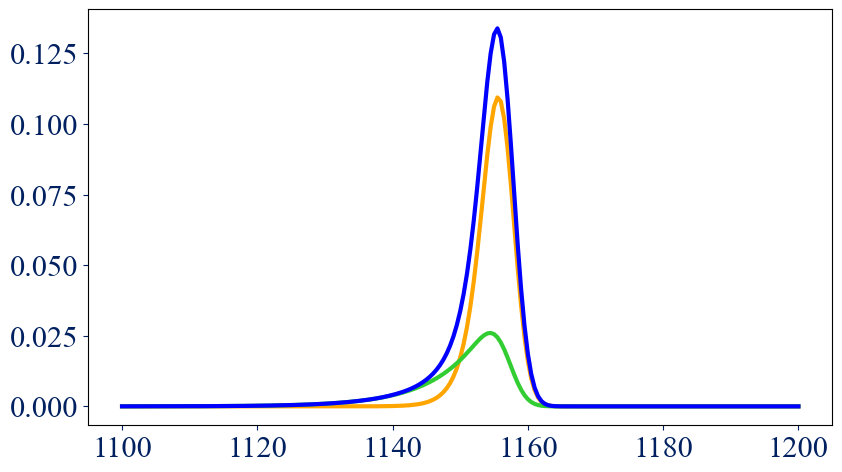

In [652]:
tau1 = 2
tau2 = 7
w1 = 0.7
w2 = 1 - w1

plt.plot(x1, w1 * energy_redistribution_expgaussian(x1, 1157, 2, tau1))
plt.plot(x1, w2 * energy_redistribution_expgaussian(x1, 1157, 2, tau2))
plt.plot(x1, w1 * energy_redistribution_expgaussian(x1, 1157, 2, tau1) + 
             w2 * energy_redistribution_expgaussian(x1, 1157, 2, tau2))

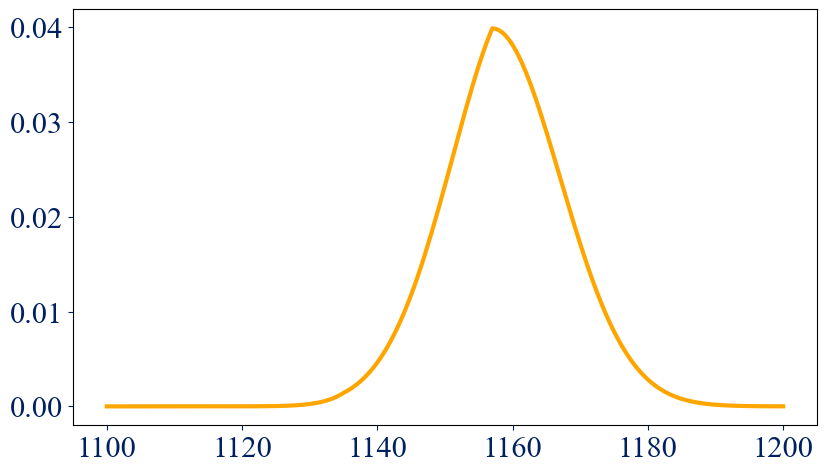

In [647]:
tau1 = 17
tau2 = 24
E1 = 1135
E2 = 1157
sigma = 10

plt.plot(x1, np.where(x1 >= E2, gaussian(x1, center=E2, sigma=sigma), 0) + 
             np.where((x1 >= E1) & (x1 < E2), gaussian(x1, center=E2, sigma=sigma) * np.exp((x1 - E2)/tau2), 0) + 
             np.where(x1 < E1, gaussian(x1, center=E2, sigma=sigma) * np.exp((x1 - E2)/tau2) * np.exp((x1 - E1)/tau1), 0)
             )

#### Plots

In [ ]:
Psi_sc = data['Psi local'] * u.rad
Chi_sc = data['Chi local'] * u.rad
# pixels = hp.ang2pix(nside=16, theta=Psi_sc.value, phi=Chi_sc.value, nest=False, lonlat=False)       # theta = polar angle (co-latitude), phi = azimuthal angle (longitude-like)

Psi_gal = data['Psi galactic'] * u.deg
Chi_gal = data['Chi galactic'] * u.deg
# Chi_gal = np.where(Chi_gal > 180 * u.deg, Chi_gal - 360 * u.deg, Chi_gal)

pixels = hp.ang2pix(nside=nside, theta=Chi_gal.value, phi=Psi_gal.value, nest=False, lonlat=True)      # theta = l, phi = b

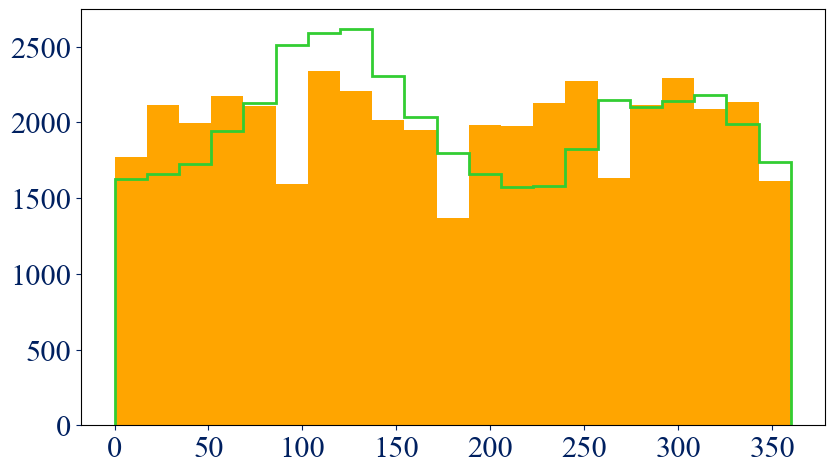

In [6]:
plt.hist(Chi_sc.to(u.deg), bins=21)
plt.hist(Chi_gal, bins=21, histtype = 'step', lw=2)     # l
plt.show()

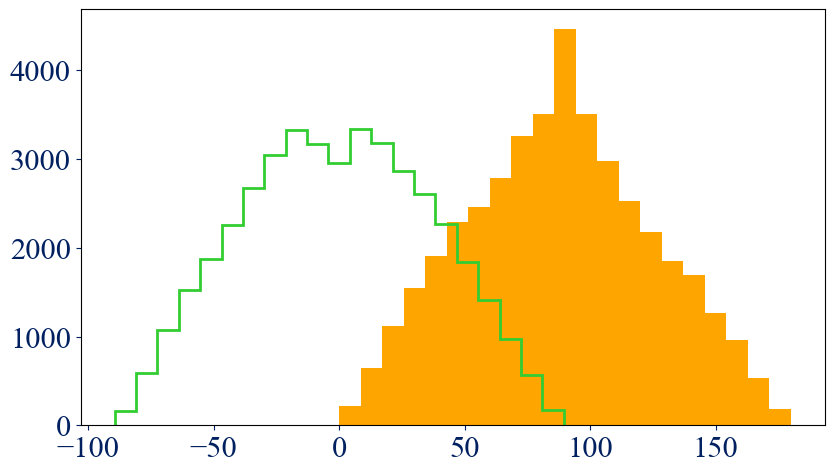

In [7]:
plt.hist(Psi_sc.to(u.deg), bins=21)
plt.hist(Psi_gal, bins=21, histtype = 'step', lw=2)     # b
plt.show()

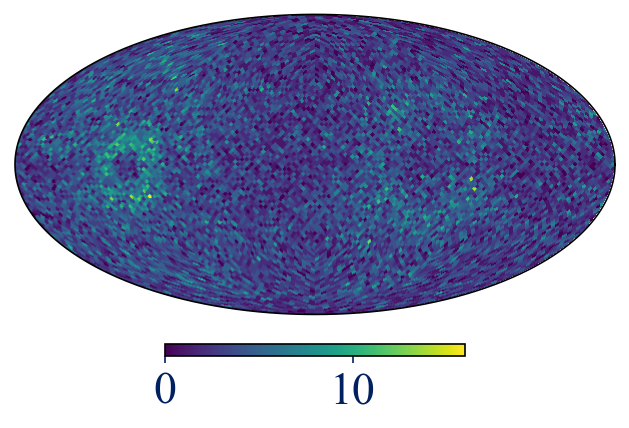

In [8]:
# Define the grid and initialize
m = HealpixMap(nside = nside, scheme = 'RING', dtype = int)

for p in pixels:
    m[p] += 1

m.plot()
plt.show()

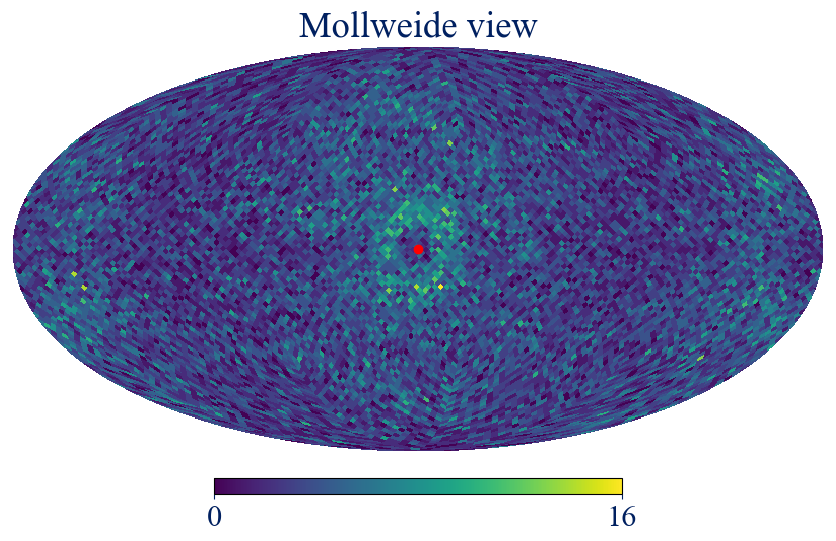

In [9]:
hp.mollview(m._data, rot=[l, b])
hp.projplot(l, b, c='r', marker='o', lonlat=True)
plt.show()

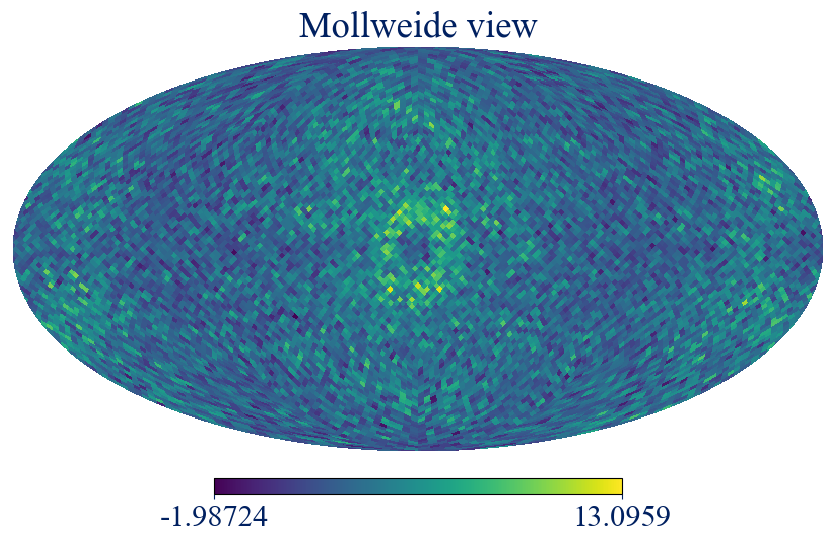

In [10]:
# Rotate the grid
rot_custom = hp.Rotator(rot=[l, b], inv=False)
data_rotated_alms = rot_custom.rotate_map_alms(m._data)

hp.mollview(data_rotated_alms)
plt.show()

#### 

In [5]:
rot_custom = hp.Rotator(rot=[l, b-90], inv=False)       # -90 ensures that Cas A is situated at hp pixel = 0

ang_rot = rot_custom(chi_gal_samples.value, psi_gal_samples.value, lonlat=True)
Psi_sc_onaxis = ang_rot[1] * u.deg      # b
Chi_sc_onaxis = ang_rot[0] * u.deg      # l

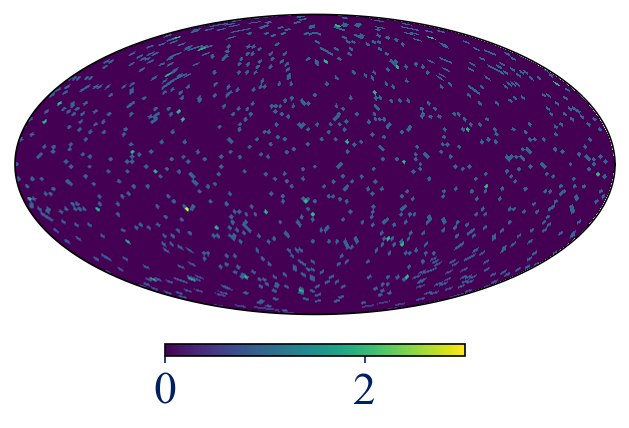

In [6]:
# Define the grid and initialize
pixels_rot = hp.ang2pix(nside=nside, theta=ang_rot[0], phi=ang_rot[1], nest=False, lonlat=True)     # l, b
m_rot = HealpixMap(nside = nside, scheme = 'RING', dtype = int)

for p in pixels_rot:
    m_rot[p] += 1

m_rot.plot()
plt.show()

### Interpolation

In [7]:
def get_all_interp_weights(dr, target: dict):
    indices = []
    weights = []

    for label in dr.axes.labels:

        if label == 'Ei':
            key = label

        elif label == 'Eps':
            key = 'Em'

        elif label == 'Phi':
            key = label

        elif label == 'Theta':
            # label = 'ThetaZeta'
            axis_type = 'Axis'      # Theta, Zeta have axis_type = 'Axis'. PsiChi axis_type = 'HealpixAxis'

            # NuLambda_sc = np.array([0])         # Placeholder. FullDetectorResponse object depends on NuLambda. Detector Response object does not. 
            # I/O with radians not degrees
            Theta, Zeta = transform_PsiChi_to_ThetaZeta(target['Phi'].to(u.rad).value, \
                                                 target['Psi_sc'].to(u.rad).value, target['Chi_sc'].to(u.rad).value)        # target['Ei', 'Em'] do not matter as we are throwing away the spectral component returned bu the function. 
            
            Theta = Theta * u.rad
            Zeta = Zeta * u.rad
            print(Theta, Zeta)

            # Theta axis
            idx, w = dr.axes['Theta'].interp_weights(Theta)
            indices.append(idx.reshape(-1))
            weights.append(w.reshape(-1))

            # Zeta axis
            idx, w = dr.axes['Zeta'].interp_weights(Zeta)
            indices.append(idx.reshape(-1))
            weights.append(w.reshape(-1))

            continue
    
        elif label == 'Zeta':
            continue

        elif label == 'PsiChi':
            key = label

        else:
            raise ValueError(f'Label: {label} is not supported')
        
        axis = dr.axes[label]

        axis_scale = axis._scale
        axis_type = str(type(axis)).split('.')[-1].strip("'>")      # XXX: Could probably be simplified using `isinstance()`

        # Scale
        if axis_scale in ['linear', 'log']:   # To ensure nonlinear binning parametrizations are converted to a linear scale.

            # Axis Type
            if axis_type in ['Axis', 'HealpixAxis']:

                if key == 'Ei':
                    idx, w = axis.interp_weights(target[key])

                elif key == 'Em':
                    centers = dr.transform_Eps_to_Em(axis.centers, target['Ei'])      # Transform coordinates to more physical units      # TODO: Generalize this
                    absdiff = np.abs(centers - target[key])                             # Calculate absolute difference to given target
                    idx = np.argpartition(absdiff, (1,2))[:2]                               # Find indices corresponding to two smallest absdiff
                    w = 1 - np.partition(absdiff, (1,2))[:2] / (centers[1] - centers[0])    # Calculate weights corresponding to two smallest absdiff

                elif key == 'Phi':
                    idx, w = axis.interp_weights(target[key])

                elif key == 'PsiChi':
                    idx, w = axis.interp_weights(SkyCoord(target['Chi_sc'], target['Psi_sc'], frame=SpacecraftFrame()))     # l, b

            else:
                raise ValueError(f'Axis type: {axis_type} is not supported')

        else:
            raise ValueError(f'{axis_scale} binning / scale scheme is not supported')
        
        indices.append(idx)
        weights.append(w)
    
    return (indices, weights)

def get_interp_response(dr, target: dict):
    """
    Currently only supports nonlinear spectral responses (
    and for a particular parametrization)
    TODO: In the future, this will also support nonlinear / 
    piecewise-linear directional responses.
    """

    # target = dict(sorted(target.items()))       # Sort dictionary by key (XXX: assuming response matrix also sorts in the same way)
    indices, weights = get_all_interp_weights(dr, target)
    perm_indices = list(itertools.product(*indices))
    perm_weights = list(itertools.product(*weights))

    if len(target) == len(dr.axes):
        pass
    else:
        warnings.warn('len(target) != len(dr.axes)')
    
    interpolated_response_value = 0
    for idx, w in zip(perm_indices, perm_weights):
        interpolated_response_value += np.prod(w) * dr.contents[idx]
    
    return interpolated_response_value

hist = dr.project('Phi', 'PsiChi')
dr2 = DetectorResponse(coord = dr.coord, edges=hist.axes, contents=hist.contents, unit=dr.unit)

#### Plots

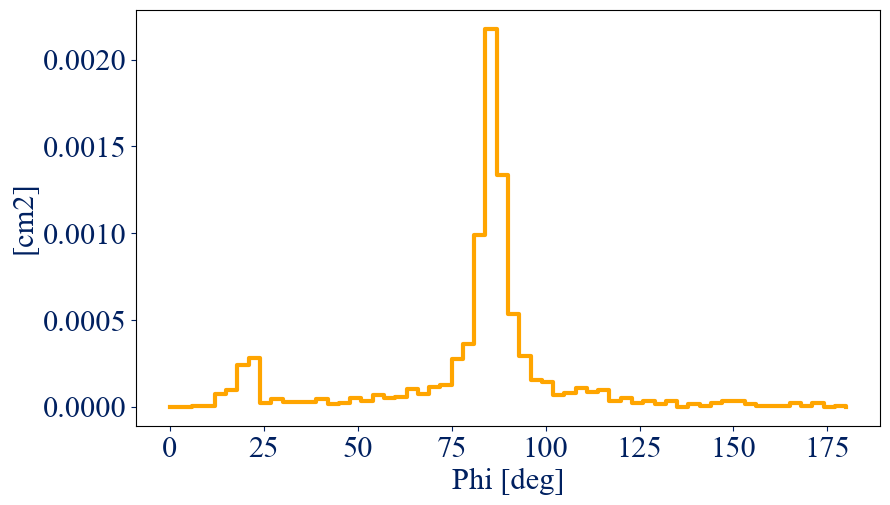

In [16]:
dr2.slice[:,1500].project('Phi').plot()
plt.show()

In [17]:
hp.pix2ang(nside=16, ipix=1500, lonlat=True)

(337.49999999999994, 2.388015463268772)

In [18]:
Phi0 = 45 * u.deg
Psi_gal0 = 2.388 * u.deg     # b
Chi_gal0 = 337.5 * u.deg       # l
target = {'Phi': Phi0, 'Psi_sc': Psi_gal0, 'Chi_sc': Chi_gal0}

get_interp_response(dr2, target)


WARNING UserWarning: len(target) != len(dr.axes)



<Quantity 1.81444463e-05 cm2>


WARNING UserWarning: len(target) != len(dr.axes)



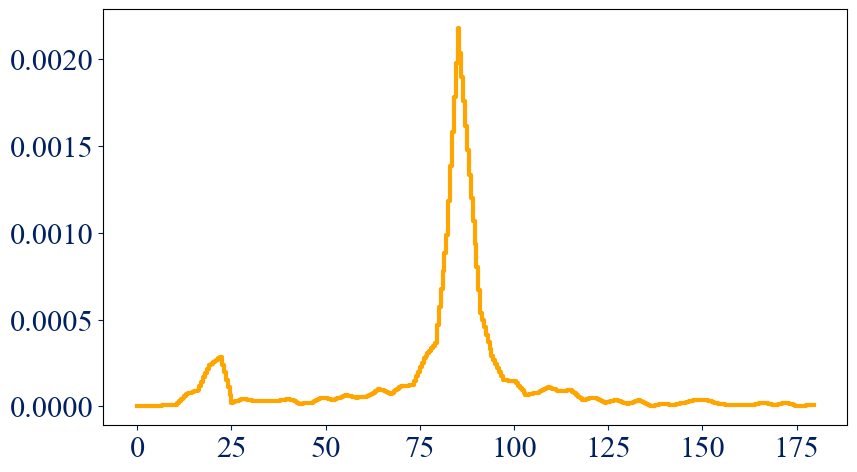

In [19]:
Phi = np.arange(180, step=0.5) * u.deg
rsp = []
for p in Phi:
    target = {'Phi': p, 'Psi_sc': Psi_gal0, 'Chi_sc': Chi_gal0}
    rsp.append(get_interp_response(dr2, target))
plt.step(Phi, Quantity(rsp))
plt.show()

### Spectrum

In [8]:
class COSILikeNew(PluginPrototype):

    def __init__(self, name, dr, exposure_time, energy_samples, phi_samples, psi_samples, chi_samples, 
                 spectrum_unit, nuisance_param, Eiedges = np.array([1154, 1160]) * u.keV, 
                 sigma_e = 5.3/2.355 * u.keV, tau_e = 1 * u.keV, spectral_smearing = None):
        super().__init__(name, nuisance_param)  # Initialize plugin base class with name and nuisance parameters

        # Define constants
        self._s2 = np.sqrt(2)
        self._s2pi = np.sqrt(2 * np.pi)
        self._tiny = 1e-12

        # Raw detector response and observation metadata
        self._dr = dr
        self._exposure_time = exposure_time.to('s')

        # Observed event-level data
        self._energy_samples = energy_samples              # Detected energies
        self._phi_samples = phi_samples                    # Azimuthal angles
        self._psi_samples = psi_samples                    # Polar angles
        self._chi_samples = chi_samples                    # Roll angles

        # Spectral integration boundaries and resolution
        self._Eiedges = Eiedges                            # True energy range to integrate over
        self._delta_E_true = Eiedges[-1] - Eiedges[0]      # Width of true energy integration window
        self._delta_E_measured = Eiedges[-1] - Eiedges[0]  # Width of measured energy range (used for convolution)

        self._spectrum_unit = spectrum_unit                # Unit of spectral flux (e.g., ph/cm²/s/keV)
        self._n_events = len(energy_samples)               # Total number of observed events
        self._sigma_e = sigma_e                            # Gaussian energy resolution (standard deviation)
        self._tau_e = tau_e                            # Gaussian energy resolution (standard deviation)

        self._effective_area = np.sum(self._dr.contents)  # Total effective area across DR matrix
        self._spectral_smearing = spectral_smearing                # Whether to ignore spectral resolution in folding

    def energy_redistribution_gaussian(self, Ei, Em, sigma_e):
        # Gaussian smearing kernel: models probability of detecting Em given true energy Ei
        return (1 / (self._s2pi * sigma_e)) * np.exp(-((Em - Ei)**2) / (2 * sigma_e**2))

    def integrated_energy_redistribution_gaussian(self, Ei, Eiedges, sigma_e):
        # Probability that an event with true energy Ei lands within measured range [E_min, E_max]
        return 0.5 * (erfc((Eiedges[0] - Ei) / (self._s2 * sigma_e)) -
                erfc((Eiedges[-1] - Ei) / (self._s2 * sigma_e)))
    
    def energy_redistribution_expgaussian(self, Ei, Em, sigma_e, tau_e):    
        # Exponentially modified gaussian smearing kernel: models probability of detecting Em given true energy Ei
        gss = -sigma_e * sigma_e / tau_e
        arg1 = -(Em + gss/2.0 - Ei) / tau_e
        arg2 = (Em + gss - Ei)/max((self._tiny * sigma_e.unit), (self._s2 * sigma_e))
        return 1 / (2 * tau_e) * np.exp(arg1) * (erf(arg2) + 1)
    
    def integrated_energy_redistribution_expgaussian(self, Ei, Eiedges, sigma_e, tau_e):
        # Numerically integrate the expgaussian kernel from E_min to E_max
        redistribution_kernel = lambda Em: self.energy_redistribution_expgaussian(Ei, Em * u.keV, sigma_e, tau_e) * u.keV

        result, error = integrate.quad(redistribution_kernel, Eiedges[0].value, Eiedges[-1].value)
        return result

    def set_model(self, likelihood_model):
        # Set the spectral model (typically ThreeML source model)
        self._likelihood_model = likelihood_model

    def _compute_predicted_a(self):
        expectation_density_list = []  # ← Each entry is the predicted density for one observed event
        Eiedges_keV = self._Eiedges / u.keV
        measured_energy_width = self._delta_E_measured
        spectral_shape_function = self._likelihood_model.source.spectrum.main.shape

        if self._spectral_smearing is None:
            integrated_flux = integrate.quad(spectral_shape_function, Eiedges_keV[0], Eiedges_keV[-1])[0] * self._spectrum_unit * u.keV
            for observed_energy, phi_angle, psi_angle, chi_angle in tqdm(zip(self._energy_samples, self._phi_samples, self._psi_samples, self._chi_samples)):
                if observed_energy < self._Eiedges[0] or observed_energy > self._Eiedges[-1]:
                    continue
                event_angles = {'Phi': phi_angle, 'Psi_sc': psi_angle, 'Chi_sc': chi_angle}
                expectation_density_list.append(get_interp_response(self._dr, event_angles) * integrated_flux * self._exposure_time)

        elif self._spectral_smearing == 'gaussian':
            for observed_energy, phi_angle, psi_angle, chi_angle in tqdm(zip(self._energy_samples, self._phi_samples, self._psi_samples, self._chi_samples)):
                if observed_energy < self._Eiedges[0] or observed_energy > self._Eiedges[-1]:
                    continue
                smeared_spectral_shape = lambda true_energy: spectral_shape_function(true_energy) * self.energy_redistribution_gaussian(true_energy * u.keV, observed_energy, self._sigma_e) * measured_energy_width
                integrated_smeared_flux = integrate.quad(smeared_spectral_shape, Eiedges_keV[0], Eiedges_keV[-1])[0] * self._spectrum_unit * u.keV
                event_angles = {'Phi': phi_angle, 'Psi_sc': psi_angle, 'Chi_sc': chi_angle}
                expectation_density_list.append(get_interp_response(self._dr, event_angles) * integrated_smeared_flux * self._exposure_time)

        elif self._spectral_smearing == 'expgaussian':
            for observed_energy, phi_angle, psi_angle, chi_angle in tqdm(zip(self._energy_samples, self._phi_samples, self._psi_samples, self._chi_samples)):
                if observed_energy < self._Eiedges[0] or observed_energy > self._Eiedges[-1]:
                    continue
                smeared_spectral_shape = lambda true_energy: spectral_shape_function(true_energy) * self.energy_redistribution_expgaussian(true_energy * u.keV, observed_energy, self._sigma_e, self._tau_e) * measured_energy_width
                integrated_smeared_flux = integrate.quad(smeared_spectral_shape, Eiedges_keV[0], Eiedges_keV[-1])[0] * self._spectrum_unit * u.keV
                event_angles = {'Phi': phi_angle, 'Psi_sc': psi_angle, 'Chi_sc': chi_angle}
                expectation_density_list.append(get_interp_response(self._dr, event_angles) * integrated_smeared_flux * self._exposure_time)

        expectation_density_array = Quantity(expectation_density_list)
        return expectation_density_array


    def _compute_predicted_c(self):
        # Compute total expected number of counts over full observation and ROI
        true_energy_edges_keV = self._Eiedges / u.keV
        spectral_shape_function = self._likelihood_model.source.spectrum.main.shape

        if self._spectral_smearing is None:
            # Without spectral smearing: use raw integrated source flux
            integrated_flux_over_roi = (
                integrate.quad(spectral_shape_function, true_energy_edges_keV[0], true_energy_edges_keV[-1])[0]
                * self._spectrum_unit * u.keV
            )

        elif self._spectral_smearing == 'gaussian':
            # With spectral smearing: integrate source flux modulated by instrument response
            folded_spectral_shape = lambda Ei: spectral_shape_function(Ei) * self.integrated_energy_redistribution_gaussian(
                Ei * u.keV, self._Eiedges, self._sigma_e)
            integrated_flux_over_roi = (
                integrate.quad(folded_spectral_shape, true_energy_edges_keV[0], true_energy_edges_keV[-1])[0]
                * self._spectrum_unit * u.keV
            )
            
        elif self._spectral_smearing == 'expgaussian':
            # With spectral smearing: integrate source flux modulated by instrument response
            folded_spectral_shape = lambda Ei: spectral_shape_function(Ei) * self.integrated_energy_redistribution_expgaussian(
                Ei * u.keV, self._Eiedges, self._sigma_e, self._tau_e)
            integrated_flux_over_roi = (
                integrate.quad(folded_spectral_shape, true_energy_edges_keV[0], true_energy_edges_keV[-1])[0]
                * self._spectrum_unit * u.keV
            )

        total_expected_counts = self._effective_area * integrated_flux_over_roi * self._exposure_time
        return total_expected_counts

    def get_log_like(self):
        # Final log-likelihood: Poisson likelihood from expectation density and total counts
        aj_array = self._compute_predicted_a()
        expected_counts = self._compute_predicted_c()
        log_like = -expected_counts + np.sum(np.log(aj_array + self._tiny))
        return log_like

    def inner_fit(self):
        # Wrapper method for fit logic
        return self.get_log_like()

    def get_number_of_data_points(self):
        return self._n_events

    def get_number_of_model_parameters(self):
        return self._likelihood_model.get_number_of_free_parameters()

In [13]:
COSILikeNew.integrated_energy_redistribution_expgaussian(cosi, 1157 * u.keV, np.array([1154, 1160])*u.keV, 2 * u.keV, 1 * u.keV)

0.7874061966541395

In [14]:
COSILikeNew.integrated_energy_redistribution_gaussian(cosi, 1157 * u.keV, np.array([1154, 1160])*u.keV, 2 * u.keV)

<Quantity 0.8663856>

#### Plots

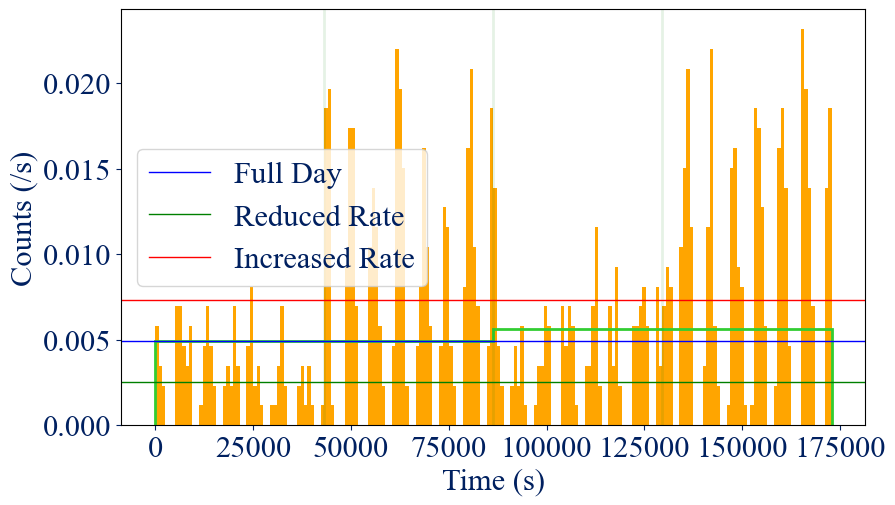

In [42]:
t0 = data['TimeTags'].min()
numdays = 2
bins = np.linspace(0, 86400*numdays, 100 * numdays + 1)
counts, _ = np.histogram(data['TimeTags'] - t0, bins=bins)
plt.stairs(counts / np.diff(bins), bins, fill=True)

counts, bins = np.histogram(data['TimeTags'] - t0, bins=np.arange(0, 86400*numdays+1, 86400))
plt.stairs(counts / np.diff(bins), bins, lw=2)

for i in range(1, numdays*2):
    plt.axvline(i * 86400/2, c='g', lw=2, alpha=0.1)

ff = 1#15/5

cond = (data['TimeTags'] < t0+86400)
plt.axhline(len(data['TimeTags'][cond]) / 86400 * ff, label='Full Day', lw=1, c='b')
cond = (data['TimeTags'] < t0+86400/2)
plt.axhline(len(data['TimeTags'][cond]) / (86400/2) * ff, label='Reduced Rate', lw=1, c='g')
cond = (data['TimeTags'] < t0 + 86400) & (data['TimeTags'] > t0 + 86400/2)
plt.axhline(len(data['TimeTags'][cond]) / (86400/2) * ff, label='Increased Rate', lw=1, c='r')

plt.xlabel('Time (s)')
plt.ylabel('Counts (/s)')
plt.legend()
plt.show()

74.0 34.0
139.0 176.0


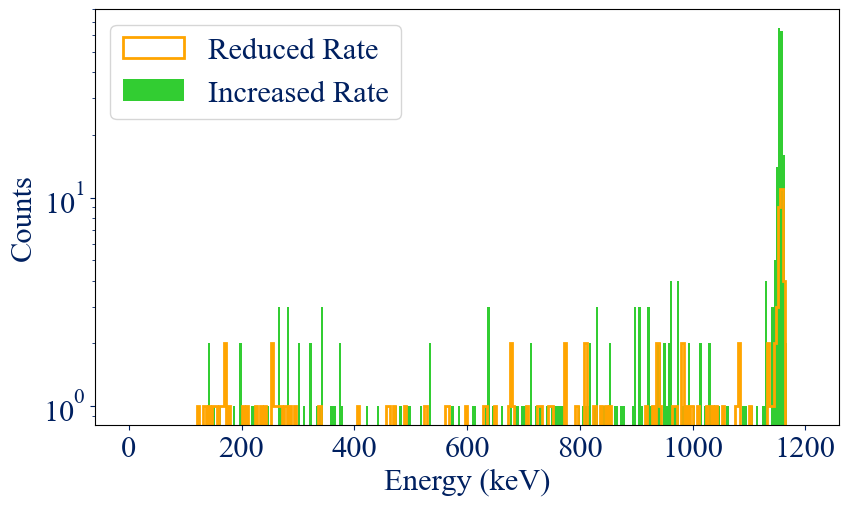

In [23]:
bins = np.linspace(0, 1200, 301)

cond = (data['TimeTags'] < t0 + 86400/2)
counts, _, _ = plt.hist(data['Energies'][cond], bins=bins, histtype='step', lw=2, label='Reduced Rate')
print(np.sum(counts[:275]), np.sum(counts[275:]))
cond = (data['TimeTags'] < t0 + 86400) & (data['TimeTags'] > t0 + 86400/2)
counts, _, _ = plt.hist(data['Energies'][cond], bins=bins, label='Increased Rate')
print(np.sum(counts[:275]), np.sum(counts[275:]))
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()
plt.show()

####

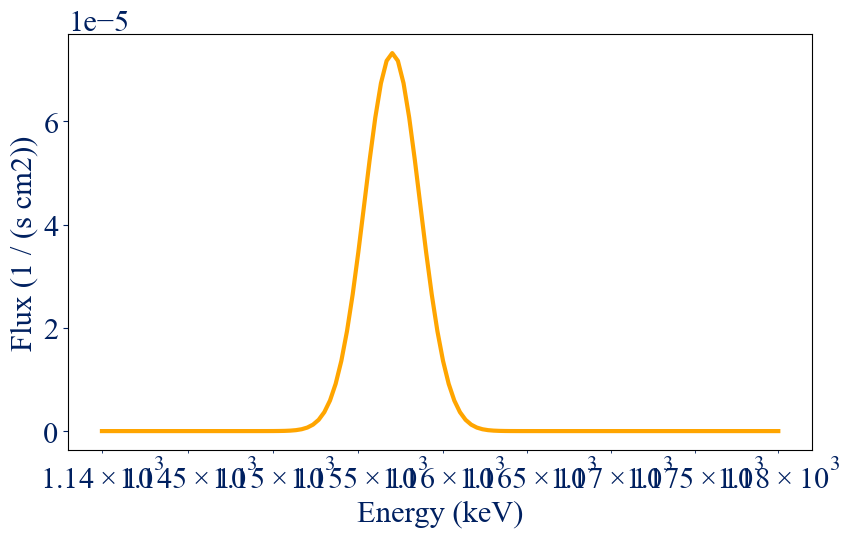

In [28]:
def spectrum_reset(spec):
    if name == 'CasAsymmetric':
        F = 3e-4 / u.cm / u.cm / u.s
        mu = 1157 * u.keV
        sigma = 3.85/2.355 * u.keV

        spec.F.value = F.value
        spec.F.min_value = F.value / 1e3
        spec.F.max_value = F.value * 1e3
        spec.F.unit = F.unit
        spec.mu.value = mu.value 
        spec.mu.min_value = mu.value - 10
        spec.mu.max_value = mu.value + 10
        spec.mu.unit = mu.unit
        spec.sigma.value = sigma.value
        spec.sigma.min_value = sigma.value - 5
        spec.sigma.max_value = sigma.value + 5
        spec.sigma.unit = sigma.unit

    else:
        # Input .source values
        F1 = 1e-4 / u.cm / u.cm / u.s
        mu1 = {'CasAfullyresolved': 1149.35, 
               'CasApartiallyresolved': 1152.41, 
               'CasAunresolved': 1153.17}
        mu1 = mu1[name] * u.keV
        sigma1 = 3.85 * u.keV / 2.355
 
        F2 = 2 * F1
        mu2 = {'CasAfullyresolved': 1160.89, 
               'CasApartiallyresolved': 1159.34, 
               'CasAunresolved': 1158.95}
        mu2 = mu2[name] * u.keV
        sigma2 = sigma1
 
        # Define the first Gaussian
        spec.F_1.value = F1.value
        spec.F_1.min_value = F1.value / 1e2
        spec.F_1.max_value = F1.value * 1e2
        spec.F_1.unit = F1.unit
        spec.mu_1.value = mu1.value
        spec.mu_1.min_value = mu1.value - 10
        spec.mu_1.max_value = mu1.value + 10
        spec.mu_1.unit = mu1.unit
        spec.sigma_1.value = sigma1.value
        spec.sigma_1.min_value = sigma1.value - 5
        spec.sigma_1.max_value = sigma1.value + 5
        spec.sigma_1.unit = sigma1.unit
 
        # Define the second Gaussian
        spec.F_2.value = F2.value
        spec.F_2.min_value = F2.value / 1e2
        spec.F_2.max_value = F2.value * 1e2
        spec.F_2.unit = F2.unit
        spec.mu_2.value = mu2.value
        spec.mu_2.min_value = mu2.value - 10
        spec.mu_2.max_value = mu2.value + 10
        spec.mu_2.unit = mu2.unit
        spec.sigma_2.value = sigma2.value
        spec.sigma_2.min_value = sigma2.value - 5
        spec.sigma_2.max_value = sigma2.value + 5
        spec.sigma_2.unit = sigma2.unit

    return spec

if name == 'CasAsymmetric':
    spectrum = Gaussian()
    spectrum = spectrum_reset(spectrum)
    spectrum_unit = spectrum.F.unit / spectrum.sigma.unit 

    spectrum.F.free = True
    spectrum.mu.free = False
    spectrum.sigma.free = False

else:
    # Create the compound model
    gaussian1 = Gaussian()
    gaussian2 = Gaussian()
    spectrum = gaussian1 + gaussian2
    spectrum = spectrum_reset(spectrum)
    spectrum_unit = spectrum.F_1.unit / spectrum.sigma_1.unit 
    
    spectrum.F_1.free = False
    spectrum.mu_1.free = True
    spectrum.sigma_1.free = False
    spectrum.F_2.free = False
    spectrum.mu_2.free = True
    spectrum.sigma_2.free = False
    

# Generate some data for plotting
xdata = np.linspace(1140, 1180, 121) * u.keV
ydata = spectrum(xdata.value) * spectrum_unit

# Plot the compound model
plt.plot(xdata.value, ydata)
plt.xlabel(f'Energy ({xdata.unit})')
plt.ylabel(f'Flux ({spectrum_unit * u.keV})')
# plt.ylim([0, 1e-5])
plt.xscale('log')
plt.show()

In [29]:
exposure_time = 92.34 * u.d * (len(energy_samples) / len(data['Energies'])) #* 4/5 #* 5/6 #* 1/4      # 3 month total, SAA cut, 25% FOV (required fudge factor based on empirical testing through above rate plots was ~0.215 = 5/24). 
                                                                                                     # By empirical testing, 4/5 is a good value for no spectral response analysis
print(len(np.where((data['Energies'] > 1128) & (data['Energies'] < 1186))[0]), len(data['Energies']))
Aeff = dr.get_effective_area

18982 41867


In [30]:
cosi = COSILikeNew('cosi',                                                     # COSI 3ML plugin
                 dr = dr2,                                                     # detector response
                 exposure_time = exposure_time,
                 energy_samples = energy_samples,
                 phi_samples = phi_samples,
                 psi_samples = Psi_sc_onaxis,
                 chi_samples = Chi_sc_onaxis, 
                 spectrum_unit = spectrum_unit,
                 Eiedges = np.array([1100, 1200]) * u.keV,
                 nuisance_param = {},                                            # background parameter)       
                 spectral_smearing = 'expgaussian'
)   

target_coord = SkyCoord.from_name('Crab').galactic
source = PointSource('source', 
                     l = target_coord.l.value,
                     b = target_coord.b.value,
                     spectral_shape = spectrum)
model = Model(source)
cosi.set_model(model)

In [31]:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit()

10:17:51 INFO      set the minimizer to minuit                                             ]8;id=542203;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=400012;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

0it [00:00, ?it/s]
WARNING UserWarning: len(target) != len(dr.axes)

1000it [00:14, 69.05it/s]
1000it [00:14, 68.76it/s]
1000it [00:15, 65.59it/s]
1000it [00:14, 68.05it/s]
1000it [00:14, 68.67it/s]
1000it [00:13, 74.30it/s]
1000it [00:13, 73.35it/s]
1000it [00:13, 73.57it/s]
1000it [00:13, 73.35it/s]
1000it [00:13, 73.59it/s]
1000it [00:13, 74.81it/s]
1000it [00:13, 74.70it/s]
1000it [00:13, 74.64it/s]
1000it [00:13, 74.82it/s]
1000it [00:13, 73.59it/s]
1000it [00:13, 73.49it/s]
1000it [00:13, 73.28it/s]
1000it [00:14, 70.49it/s]
1000it [00:13, 73.88it/s]
1000it [00:13, 74.58it/s]
1000it [00:13, 74.48it/s]
1000it [00:13, 73.16it/s]
1000it [00:13, 73.73it/s]
1000it [00:13, 74.11it/s]
1000it [00:13, 71.58it/s]


10:25:20 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.3.       ]8;id=151448;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=116679;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1147.0.   ]8;id=804937;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=540000;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

Best fit values:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,2709.3727388716625
total,2709.3727388716625


Values of statistical measures:

,statistical measures
AIC,5420.749485759357
BIC,5425.653233022307


(                                    value  negative_error  positive_error  \
 source.spectrum.main.Gaussian.F  0.000103       -0.000005        0.000005   
 
                                     error         unit  
 source.spectrum.main.Gaussian.F  0.000005  1 / (s cm2)  ,
          -log(likelihood)
 cosi   2709.3727388716625
 total  2709.3727388716625)

In [32]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Gaussian.F,(1.03 +/- 0.05) x 10^-4,1 / (s cm2)


Correlation matrix:

1.00


Values of -log(likelihood) at the minimum:

...

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.3.       ]8;id=541830;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=841557;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1147.0.   ]8;id=112049;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=352650;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.3.       ]8;id=238881;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=436859;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1147.0.   ]8;id=334050;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=895870;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

  * source (point source):
    * position:
      * l:
        * value: 184.5546550034881
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: -5.783339352016454
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Gaussian:
          * F:
            * value: 0.00010273460531865495
            * desc: Integral between -inf and +inf. Fix this to 1 to obtain a Normal distribution
            * min_value: 3.0e-07
            * max_value: 0.3
            * unit: s-1 cm-2
            * is_normalization: false
          * mu:
            * value: 1157.0
            * desc: Central value
            * min_value: 1147.0
            * max_value: 1167.0
            * unit: keV
            * is_normalization: false
          * sigma:


In [260]:
energy = np.linspace(1140*u.keV,1180*u.keV, 81).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    spectrum_inj = spectrum_reset(spec=spectrum)
    flux_inj[i] = spectrum_inj.evaluate_at(e)

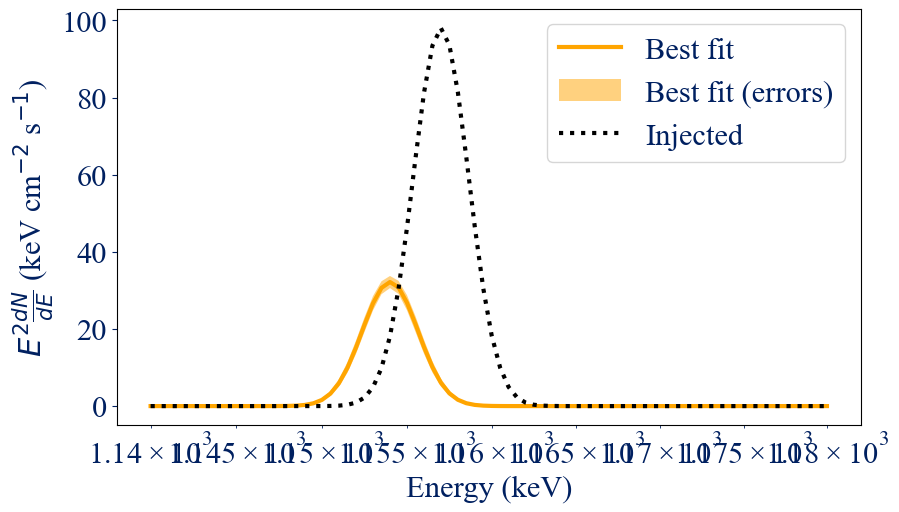

In [261]:
fig,ax = plt.subplots()

plt.plot(energy, energy*energy*flux_median, label = "Best fit")
plt.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
plt.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

plt.xscale("log")
# ax.set_yscale("log")

plt.xlabel("Energy (keV)")
plt.ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

plt.legend()
plt.show()

In [34]:
def scan_log_likelihood(cosi, spectrum_attr1, values1, spectrum_attr2=None, values2=None):
    logL_results = []

    if spectrum_attr2 is None:
        # One-dimensional scan
        for val1 in values1:
            setattr(cosi._likelihood_model.source.spectrum.main.shape, spectrum_attr1, val1)
            logL = cosi.get_log_like()
            logL_results.append(logL)
        return np.array(logL_results)

    else:
        # Two-dimensional scan
        logL_grid = np.zeros((len(values1), len(values2)))
        for i, val1 in enumerate(values1):
            setattr(cosi._likelihood_model.source.spectrum.main.shape, spectrum_attr1, val1)
            for j, val2 in enumerate(values2):
                setattr(cosi._likelihood_model.source.spectrum.main.shape, spectrum_attr2, val2)
                logL_grid[i, j] = cosi.get_log_like()
        return logL_grid

def plot_logL_1d(values, logLs, xlabel, injected_value=None):
    plt.figure(figsize=(8, 5))
    plt.plot(values, logLs, lw=2)
    if injected_value is not None:
        plt.axvline(injected_value, ls=':', c='g', label='Injected')
    plt.axvline(values[np.nanargmax(logLs)], ls='--', label='Fit')
    plt.xlabel(xlabel)
    plt.ylabel("Log-Likelihood")
    plt.title(f"Log-Likelihood vs. {xlabel}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_logL_2d(values1, values2, logL_grid, xlabel, ylabel):
    plt.figure(figsize=(8, 6))
    plt.contourf(values1, values2, logL_grid.T, levels=50, cmap='viridis')
    plt.colorbar(label="Log-Likelihood")
    plt.xscale('log')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f"Log-Likelihood vs. {xlabel} and {ylabel}")
    plt.tight_layout()
    plt.show()

0it [00:00, ?it/s]
WARNING UserWarning: len(target) != len(dr.axes)

1000it [00:20, 48.14it/s]
1000it [00:19, 50.51it/s]
1000it [00:19, 51.44it/s]
1000it [00:19, 51.84it/s]
1000it [00:19, 51.03it/s]
1000it [00:19, 52.49it/s]
1000it [00:18, 54.58it/s]
1000it [00:18, 55.12it/s]
1000it [00:17, 56.80it/s]
1000it [00:17, 58.72it/s]
1000it [00:21, 46.49it/s]
1000it [00:21, 47.56it/s]
1000it [00:19, 50.42it/s]
1000it [00:19, 50.45it/s]
1000it [00:19, 51.90it/s]
1000it [00:18, 53.16it/s]
1000it [00:18, 55.22it/s]
1000it [00:17, 56.89it/s]
1000it [00:17, 58.13it/s]
1000it [00:16, 59.52it/s]
1000it [00:20, 49.06it/s]
1000it [00:19, 50.89it/s]
1000it [00:19, 52.33it/s]
1000it [00:18, 54.12it/s]
1000it [00:18, 54.10it/s]
1000it [00:18, 54.23it/s]
1000it [00:18, 54.53it/s]
1000it [00:18, 54.75it/s]
1000it [00:18, 55.52it/s]
1000it [00:17, 56.44it/s]
1000it [00:14, 69.15it/s]
1000it [00:16, 62.33it/s]
1000it [00:17, 57.87it/s]
1000it [00:17, 55.63it/s]
1000it [00:18, 54.89it/s]
1000it [00:18, 55.15i

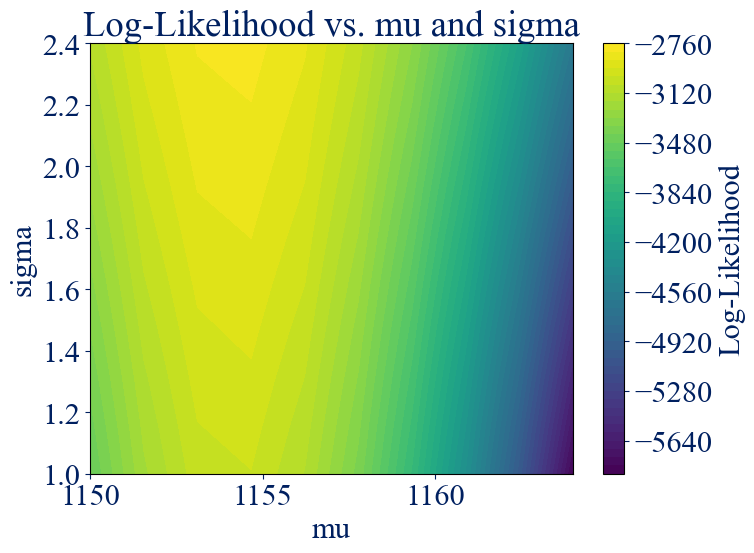

In [16]:
F_values = np.geomspace(3e-4/10, 3e-4*100, 16)
mu_values = np.linspace(1150, 1164, 10)
sigma_values = np.linspace(1.0, 2.4, 10)

logL_grid = scan_log_likelihood(cosi, "mu", mu_values, "sigma", sigma_values)
plot_logL_2d(mu_values, sigma_values, logL_grid, xlabel="mu", ylabel="sigma")

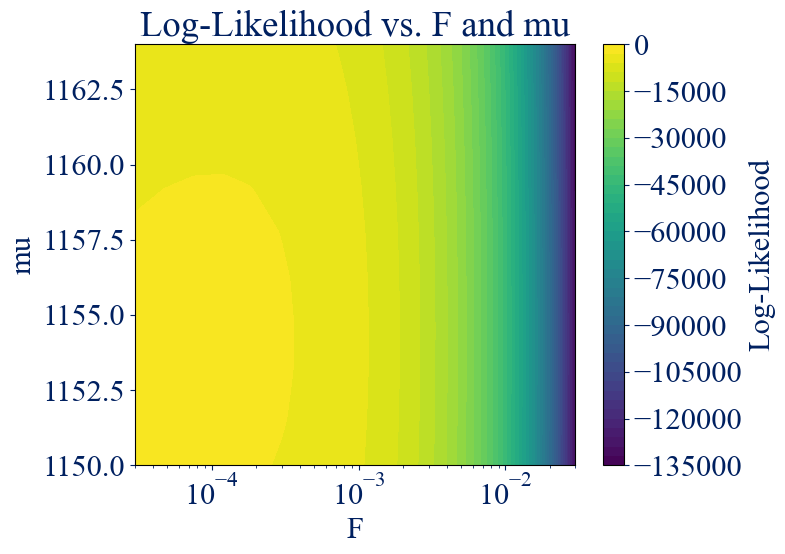

In [35]:
F_values = np.geomspace(3e-4/10, 3e-4*100, 16)
mu_values = np.linspace(1150, 1164, 10)
sigma_values = np.linspace(1.0, 2.4, 10)

# logL_grid = scan_log_likelihood(cosi, "F", F_values, "mu", mu_values)
plot_logL_2d(F_values, mu_values, logL_grid, xlabel="F", ylabel="mu")

In [22]:
cosi_spectrum = cosi._likelihood_model.source.spectrum.main.shape
cosi_spectrum = spectrum_reset(spec=cosi_spectrum)

logL_values = []
prefactor_values = np.geomspace(1e-4/10, 1e-4*100, 16)
for F_value in prefactor_values:
    cosi._likelihood_model.source.spectrum.main.shape.F.value = F_value
    logL_values.append(cosi.get_log_like())

0it [00:00, ?it/s]
WARNING UserWarning: len(target) != len(dr.axes)

1000it [00:12, 78.28it/s]
1000it [00:13, 71.49it/s]
1000it [00:12, 77.16it/s]
1000it [00:13, 76.35it/s]
1000it [00:13, 75.59it/s]
1000it [00:13, 72.55it/s]
1000it [00:14, 69.84it/s]
1000it [00:14, 67.43it/s]
1000it [00:15, 64.16it/s]
1000it [00:15, 64.28it/s]
1000it [00:16, 59.82it/s]
1000it [00:16, 60.33it/s]
1000it [00:17, 57.39it/s]
1000it [00:18, 55.38it/s]
1000it [00:18, 54.70it/s]
1000it [00:18, 54.57it/s]


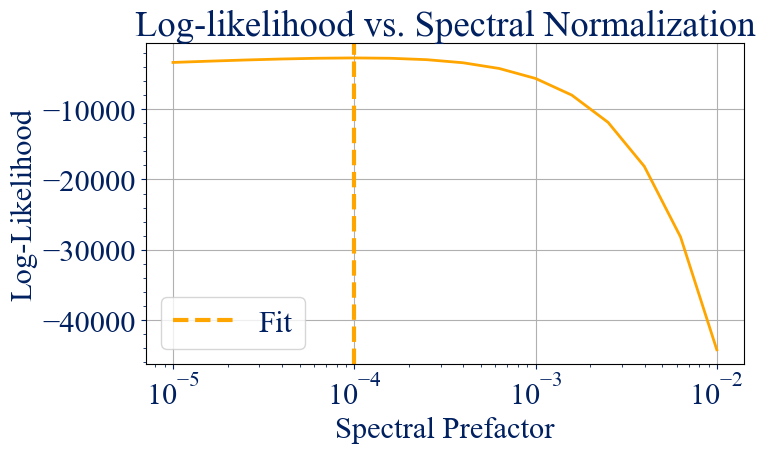

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(prefactor_values, logL_values, lw=2)
plt.xscale('log')
plt.xlabel("Spectral Prefactor")
plt.ylabel("Log-Likelihood")
plt.title("Log-likelihood vs. Spectral Normalization")
# plt.axvline(F.value, ls=':', c='g', label='Injected')
plt.axvline(prefactor_values[np.argmax(logL_values)], ls='--', label='Fit')
# plt.axhline(np.max(logL_values), ls='--', label='Fit')
plt.legend()
# plt.ylim(bottom=0)
plt.minorticks_on()
plt.grid(True)
plt.tight_layout()
plt.show()

In [253]:
cosi_spectrum = cosi._likelihood_model.source.spectrum.main.shape
cosi_spectrum = spectrum_reset(spec=cosi_spectrum)

logL_values = []
values = np.linspace(1150, 1164, 15)
for mu_value in values:
    cosi_spectrum.mu.value = mu_value
# for exp_time in np.linspace(17.44, 18.04, 4) * u.d:
#     cosi._exposure_time = exp_time
#     values = np.linspace(1, 2.4, 15)
#     for sigma_value in values:
#         cosi_spectrum.sigma.value = sigma_value
    logL_values.append(cosi.get_log_like())

0it [00:00, ?it/s]
WARNING UserWarning: len(target) != len(dr.axes)

1000it [00:00, 1251.31it/s]
1000it [00:00, 1285.92it/s]
1000it [00:00, 1214.45it/s]
1000it [00:00, 1241.18it/s]
1000it [00:00, 1234.75it/s]
1000it [00:00, 1264.66it/s]
1000it [00:00, 1312.40it/s]
1000it [00:00, 1301.57it/s]
1000it [00:00, 1311.44it/s]
1000it [00:00, 1297.12it/s]
1000it [00:00, 1296.01it/s]
1000it [00:00, 1311.93it/s]
1000it [00:00, 1278.08it/s]
1000it [00:00, 1306.85it/s]
1000it [00:00, 1307.29it/s]


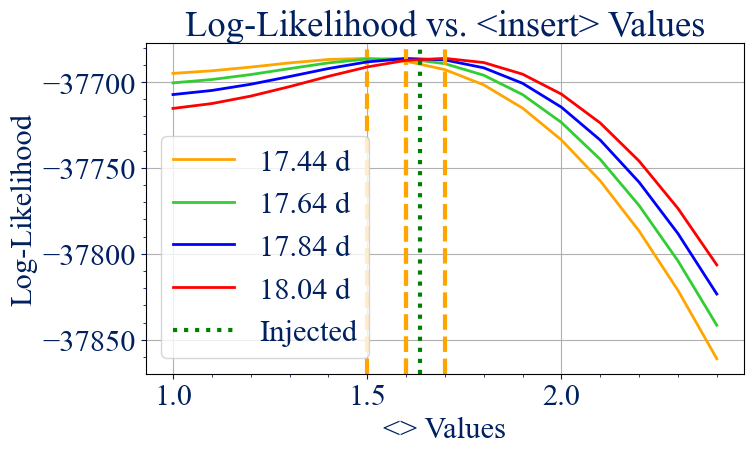

In [ ]:
plt.figure(figsize=(8, 5))
# plt.plot(values, logL_values, lw=2)
for logL, exp_time in zip(np.reshape(logL_values, (4,15)), np.linspace(17.44, 18.04, 4)*u.d):
    plt.plot(values, logL, lw=2, label=f'{exp_time}')
    plt.axvline(values[np.nanargmax(logL)], ls='--')
# plt.xscale('log')
plt.xlabel("<> Values")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood vs. <insert> Values")
# plt.axvline(mu.value, ls=':', c='g', label='Injected')
plt.axvline(sigma.value, ls=':', c='g', label='Injected')
# plt.axvline(values[np.nanargmax(logL_values)], ls='--', label='Fit')
# plt.axhline(np.max(logL_values), ls='--', label='Fit')
# plt.ylim(bottom=-40000)
plt.minorticks_on()
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

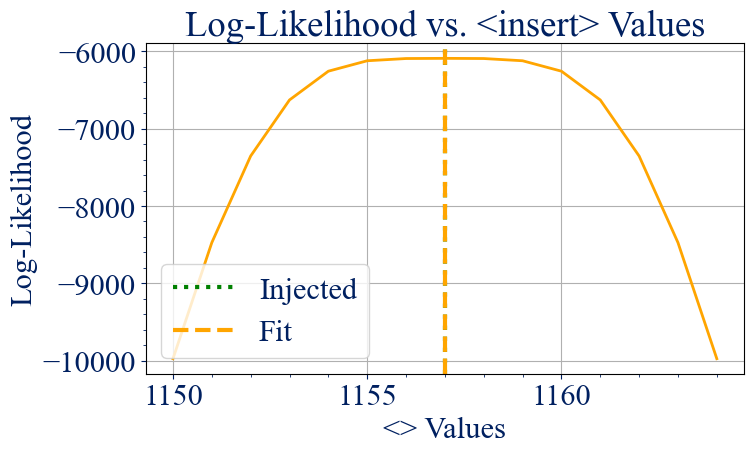

In [254]:
plt.figure(figsize=(8, 5))
plt.plot(values, logL_values, lw=2)
# plt.xscale('log')
plt.xlabel("<> Values")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood vs. <insert> Values")
plt.axvline(mu.value, ls=':', c='g', label='Injected')
plt.axvline(values[np.nanargmax(logL_values)], ls='--', label='Fit')
# plt.axhline(np.max(logL_values), ls='--', label='Fit')
# plt.ylim(bottom=-40000)
plt.minorticks_on()
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

#### Interpolation testing

In [29]:
target = {'Phi': 2.2923 * u.rad, 'Psi_sc': -12.9791 * u.deg, 'Chi_sc': -138.916 * u.deg}
get_interp_response(dr2, target)


WARNING UserWarning: len(target) != len(dr.axes)



<Quantity 4.78309265e-05 cm2>

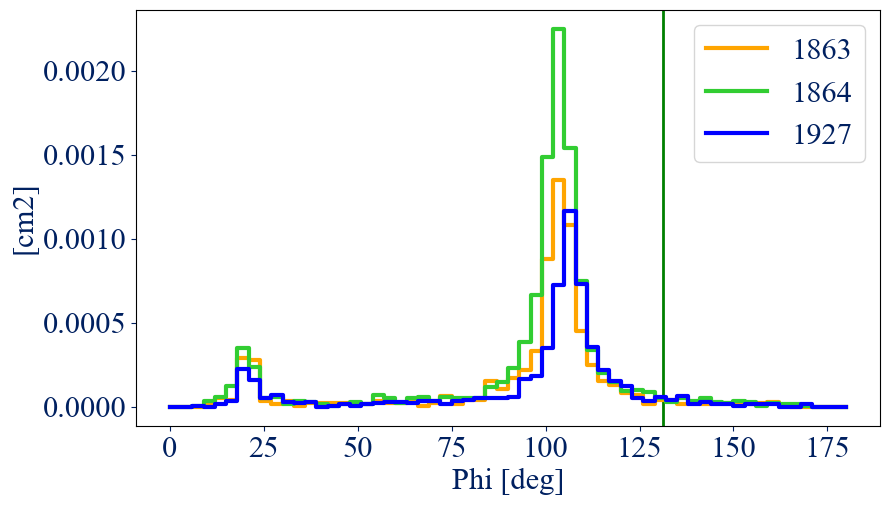

In [ ]:
ax, _ = dr2.slice[:, 1863].project('Phi').plot(label='1863')
dr2.slice[:, 1864].project('Phi').plot(ax=ax, label='1864')
dr2.slice[:, 1927].project('Phi').plot(ax=ax, label='1927')
plt.axvline(target['Phi'].to(u.deg).value, lw=2, c='g')
plt.legend()